# Bernstein-Vazirani Algorithm

In this notebook, we will implement the Bernstein-Vazirani algorithm using Qiskit. The Bernstein-Vazirani algorithm is a quantum algorithm that determines a hidden binary string with a single query, showcasing the power of quantum computing over classical methods.
We are going to follow the Medium Guide [Bernstein-Vazirani algorithm](https://medium.com/@_monitsharma/learn-quantum-computing-with-qiskit-bernstein-vazirani-algorithm-fa1300517624).

## Import Required Libraries

In [23]:
# importing Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# import basic plot tools
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# importing IBM Q Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [7]:
n = 3  # number of qubits used to represent s
s = "011"  # the hidden binary string

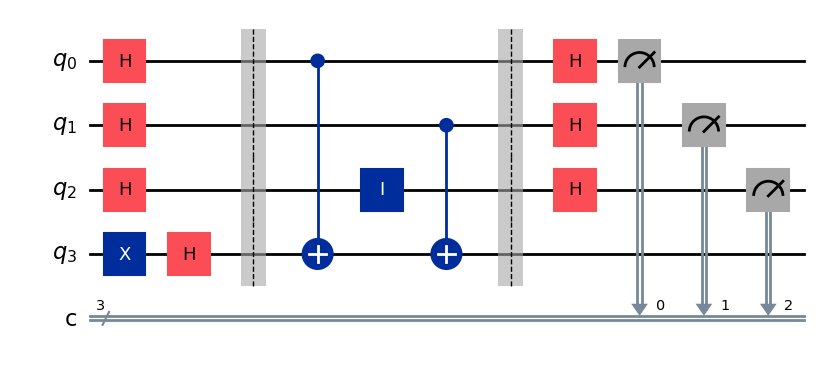

In [8]:
# We need a circuit with n qubits, plus one auxiliary qubit
# Also need n classical bits to write the output to
bv_circuit = QuantumCircuit(n + 1, n)

# put auxiliary in state |->
bv_circuit.x(n)
bv_circuit.h(n)

# Apply Hadamard gates before querying the oracle
for i in range(n):
    bv_circuit.h(i)

# Apply barrier
bv_circuit.barrier()

# Apply the inner-product oracle
s = s[::-1]  # reverse s to fit qiskit's qubit ordering
for q in range(n):
    if s[q] == "0":
        bv_circuit.id(q)
    else:
        bv_circuit.cx(q, n)

# Apply barrier
bv_circuit.barrier()

# Apply Hadamard gates after querying the oracle
for i in range(n):
    bv_circuit.h(i)

# Measurement
for i in range(n):
    bv_circuit.measure(i, i)

bv_circuit.draw("mpl")

### Using Local Simulators

If you want a more detailed explanation of every step of the algorithm, I highly recommend checking the [Bernstein-Vazirani IBM Notebook](./bernstein-vazirani-ibm.ipynb).

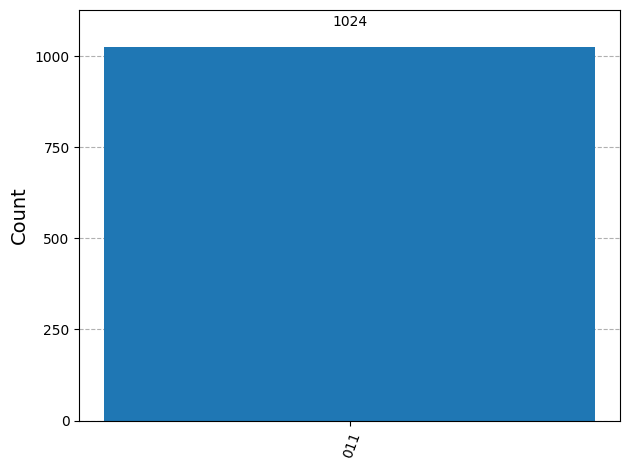

In [ ]:
# use local simulator
aer_sim = AerSimulator()
bv_circuit_transpiled = transpile(bv_circuit, aer_sim)
shots = 1024
results = aer_sim.run(bv_circuit_transpiled, shots=shots).result()
answer = results.get_counts()

plot_histogram(answer)

As we can see, in the local simulator the results is always correct, we get the key `011` with 100% probability.

### Using Real Quantum Computers

If you want a more detailed explanation of how to use the real quantum devices in this problem, please check the [Bernstein-Vazirani IBM Notebook](./bernstein-vazirani-ibm.ipynb).

In [ ]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="ENTER API TOKEN HERE",
    overwrite=True,
)

In [20]:
service = QiskitRuntimeService(channel="ibm_quantum_platform")
candidates = service.backends(simulator=False, operational=True, min_num_qubits=5)

if not candidates:
    print("There are no available backends that meet the criteria.")
else:
    backend = min(
        candidates, key=lambda b: b.status().pending_jobs
    )  # least busy backend

    print(f"The least busy backend is: {backend.name}")
    print(f"Pending jobs: {backend.status().pending_jobs}")

qiskit_runtime_service.__init__:WARNING:2026-06-30 16:09:31,591: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: TFG-Edhey. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 16:09:31,593: Loading instance: TFG-Edhey, plan: open


The least busy backend is: ibm_marrakesh
Pending jobs: 1


In [24]:
# Run the circuit on the least busy backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(bv_circuit)
sampler = Sampler(backend)
job = sampler.run([isa_circuit], shots=1024)

print(f"Job ID: {job.job_id()}")

Job ID: d91tqrnccmks73d5ron0


{'011': 937, '111': 24, '010': 10, '000': 39, '001': 11, '100': 1, '101': 2}


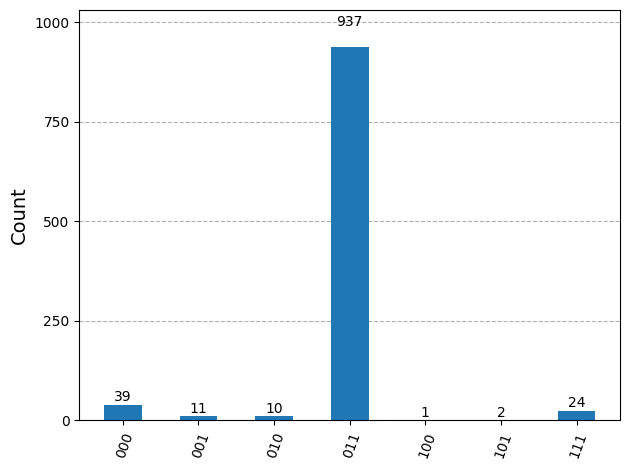

In [28]:
# Get the results from the computation
results = job.result()
pub_result = results[0].data.c.get_counts()
print(pub_result)
plot_histogram(pub_result)

In the real quantum computers, we do not get the correct result always. As we can check in the histogram, we get the key `011` most of the time, but we also get other results with a small probability. This is due to the noise and errors present in real quantum devices.